In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import json

In [2]:
path = Path('hw7_saved_make_model')

In [3]:
all_cams = ['sc1','sc2','sc3','sc4']

In [4]:
path.resolve()

WindowsPath('C:/Users/thuy1/OneDrive/Documents/YorkU/Research Assistant/Data/Evaluating Best frames/HW7_Results/hw7_saved_make_model')

In [5]:
all_cams_make_model = dict()
for cam in all_cams:
    with open(path/f'seg23_{cam}_make_model_20240319.json', 'r') as f:
        one_cam = json.load(f)
        all_cams_make_model[cam] = one_cam[list(one_cam.keys())[0]]

### Eval the results

In [6]:
#Load 4 sets of results in
#Load in with pandas
anno1 = 'combined'
anno2 = 'aime'
anno3 = 'ceci'

# suffix2 = '_enforce'
angle1 = 'avg'
angle2 = 'pizlo'

#bounds or not
bounds1 = 'bounds'
bounds2 = 'nobounds'

#fixtire or not
fixtire1 = '_fixtirefails'
fixtire2 = ''


fname_1 = f'hw7_results_{anno2}_{angle1}_{bounds1}{fixtire2}.txt'
fname_2 = f'hw7_results_{anno2}_{angle1}_{bounds1}{fixtire2}.txt'
print(fname_1,fname_2)

use_four = False
if use_four:
    fname_3 = f'hw7_results_{anno1}_{angle1}_{bounds1}{fixtire2}.txt'
    fname_4 = f'hw7_results_{anno1}_{angle1}_{bounds1}{fixtire2}.txt'
    print(fname_3,fname_4)

hw7_results_aime_avg_bounds.txt hw7_results_aime_avg_bounds.txt


In [7]:
path = Path('.')

In [8]:
df1 = pd.read_csv(path/fname_1, delim_whitespace=True, header=None)
df2 = pd.read_csv(path/fname_2, delim_whitespace=True, header=None)
if use_four:
    df3 = pd.read_csv(path/fname_3, delim_whitespace=True, header=None)
    df4 = pd.read_csv(path/fname_4, delim_whitespace=True, header=None)
#Name the columns
col_names = ["camera","target", "annotated_car_id",
       "num_sym_pairs","bbox_2D_height",
             "reproj_error","gt_heading_angle",
             "pred_heading_angle","angle_difference",
             "dist_base_gt_bbox","dist_base_pred_bbox",
             "dist_base_bbox_diff","dist_nearest_corner_gt_bbox",
             "dist_nearest_corner_pred_bbox","dist_nearest_corner_diff",
             "iou","iou_bev","mounting_height","ds",
            "PRED_OL","PRED_OW","PRED_OH","PRED_WB","LD_OL","LD_OW","LD_OH","PRED_WWOM","tire_both_sides","has_mirrors","dist_to_move",
            "LD_OW_NON","LD_OH_NON","LD_OL_NON","LENGTH_BY_GAUSSIAN","NUM_TIRES"]
assert len(col_names) == df1.shape[-1]
col_names = ["camera", "target","annotated_car_id"] + [i for i in col_names if (i != "target" and i != "annotated_car_id") and i!= "camera"]
df1.columns = col_names
df2.columns = col_names
if use_four: 
    df3.columns = col_names
    df4.columns = col_names

### Excluding cameras
df1 = df1[(df1.camera != 'lc1')& (df1.camera != 'lc2')]
df2 = df2[(df2.camera != 'lc1')& (df2.camera != 'lc2')]
if use_four: 
    df3 = df3[(df3.camera != 'lc1')& (df3.camera != 'lc2')]
    df4 = df4[(df2.camera != 'lc1')& (df4.camera != 'lc2')]

merge_cols = ['camera','target', 'annotated_car_id']
# dims = ["OH","OL","OW"WWOM]
# def compare_dims(row):
#     for c in dims:
#         row[f"DIFF_{c}"] = row[f"PRED_{c}"]-row[f"LD_{c}"]
#     return row

# df1 = df1.apply(lambda row: compare_dims(row), axis = 1)
# df2 = df2.apply(lambda row: compare_dims(row), axis = 1)
# for c in dims:
#     df1[f"ABS_DIFF_{c}"] = df1[f"DIFF_{c}"].apply(abs)
# for c in dims:
#     df2[f"ABS_DIFF_{c}"] = df2[f"DIFF_{c}"].apply(abs)
    
# if use_four:
#     df3 = df3.apply(lambda row: compare_dims(row), axis = 1)
#     df4 = df4.apply(lambda row: compare_dims(row), axis = 1)
#     for c in dims:
#         df3[f"ABS_DIFF_{c}"] = df3[f"DIFF_{c}"].apply(abs)
#     for c in dims:
#         df4[f"ABS_DIFF_{c}"] = df4[f"DIFF_{c}"].apply(abs)

df1['dist_base_bbox_diff_abs'] = df1['dist_base_bbox_diff'].apply(abs)
df2['dist_base_bbox_diff_abs'] = df2['dist_base_bbox_diff'].apply(abs)
df1['dist_nearest_corner_diff_abs'] = df1['dist_nearest_corner_diff'].apply(abs)
df2['dist_nearest_corner_diff_abs'] = df2['dist_nearest_corner_diff'].apply(abs)
if use_four:
    df3['dist_base_bbox_diff_abs'] = df3['dist_base_bbox_diff'].apply(abs)
    df4['dist_base_bbox_diff_abs'] = df4['dist_base_bbox_diff'].apply(abs)
    df3['dist_nearest_corner_diff_abs'] = df3['dist_nearest_corner_diff'].apply(abs)
    df4['dist_nearest_corner_diff_abs'] = df4['dist_nearest_corner_diff'].apply(abs)
df1 = df1[df1.dist_base_gt_bbox <=150 ]
df2 = df2[df2.dist_base_gt_bbox <=150 ]
if use_four:
    df3 = df3[df3.dist_base_gt_bbox <=150 ]
    df4 = df4[df4.dist_base_gt_bbox <=150 ]


### Refine dimension
refine_dim = False
if refine_dim:
    metric_to_check = 'PRED_OW'
    thres_to_check = 1.56*0.5 #From DB
    print(len(df1[(df1[metric_to_check] < thres_to_check)]), 'violate dimension')
    print(len(df2[(df2[metric_to_check] < thres_to_check)]), 'violate dimension')
    if use_four:
        print(len(df3[(df3[metric_to_check] < thres_to_check)]), 'violate dimension')
        print(len(df4[(df4[metric_to_check] < thres_to_check)]), 'violate dimension')
    # print(df1[df1[metric_to_check] < thres_to_check][['target','annotated_car_id','dist_base_gt_bbox','dist_base_bbox_diff_abs',metric_to_check]].sample(n=10))
    df1 = df1[~(df1[metric_to_check] < thres_to_check)]
    df2 = df2[~(df2[metric_to_check] < thres_to_check)]
    if use_four:
        df3 = df3[~(df3[metric_to_check] < thres_to_check)]
        df4 = df4[~(df4[metric_to_check] < thres_to_check)]
    metric_to_check = 'PRED_WWOM'
    thres_to_check = 1.56*0.5 #From DB
    print(len(df1[(df1[metric_to_check] < thres_to_check)]), 'violate dimension')
    print(len(df2[(df2[metric_to_check] < thres_to_check)]), 'violate dimension')
    if use_four:
        print(len(df3[(df3[metric_to_check] < thres_to_check)]), 'violate dimension')
        print(len(df4[(df4[metric_to_check] < thres_to_check)]), 'violate dimension')
    # print(df1[df1[metric_to_check] < thres_to_check][['target','annotated_car_id','dist_base_gt_bbox','dist_base_bbox_diff_abs',metric_to_check]].sample(n=10))
    df1 = df1[~(df1[metric_to_check] < thres_to_check)]
    df2 = df2[~(df2[metric_to_check] < thres_to_check)]
    if use_four:
        df3 = df3[~(df3[metric_to_check] < thres_to_check)]
        df4 = df4[~(df4[metric_to_check] < thres_to_check)]


df1_before_merge = len(df1)
df2_before_merge = len(df2)
print(df1_before_merge, df2_before_merge)

assert len(df1[df1.duplicated(merge_cols, keep=False)]) == 0, 'NO duplicate rows'
assert len(df2[df2.duplicated(merge_cols, keep=False)]) == 0, 'NO duplicate rows'
if use_four:
    assert len(df3[df3.duplicated(merge_cols, keep=False)]) == 0, 'NO duplicate rows'
    assert len(df4[df4.duplicated(merge_cols, keep=False)]) == 0, 'NO duplicate rows'

if use_four:
    mdf = df1.merge(df2, on=merge_cols).merge(df3, on=merge_cols).merge(df4, on=merge_cols)
else:
    mdf = df1.merge(df2, on=merge_cols)

df1 = df1[df1.apply(lambda row: (row['camera'], row['target'], row['annotated_car_id']) in zip(mdf['camera'],mdf['target'], mdf['annotated_car_id']), axis=1)]
df2 = df2[df2.apply(lambda row: (row['camera'], row['target'], row['annotated_car_id']) in zip(mdf['camera'],mdf['target'], mdf['annotated_car_id']), axis=1)]

if use_four:
    df3 = df3[df3.apply(lambda row: (row['camera'], row['target'], row['annotated_car_id']) in zip(mdf['camera'],mdf['target'], mdf['annotated_car_id']), axis=1)]
    df4 = df4[df4.apply(lambda row: (row['camera'], row['target'], row['annotated_car_id']) in zip(mdf['camera'],mdf['target'], mdf['annotated_car_id']), axis=1)]

assert len(df1) == len(df2)
if use_four:
    assert len(df3) == len(df4)
    assert len(df2) == len(df3)
df1 = df1.sort_values(by=merge_cols).reset_index()
df1.drop('index', axis=1, inplace=True)
df2 = df2.sort_values(by=merge_cols).reset_index()
df2.drop('index', axis=1, inplace=True)
if use_four:
    df3 = df3.sort_values(by=merge_cols).reset_index()
    df3.drop('index', axis=1, inplace=True)  
    df4 = df4.sort_values(by=merge_cols).reset_index()
    df4.drop('index', axis=1, inplace=True)  

110 110


C:\Users\thuy1\AppData\Local\Temp\ipykernel_42120\1419218777.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = pd.read_csv(path/fname_1, delim_whitespace=True, header=None)
C:\Users\thuy1\AppData\Local\Temp\ipykernel_42120\1419218777.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(path/fname_2, delim_whitespace=True, header=None)


### Find out the mirrors statistics

In [9]:
df1[df1.PRED_WWOM>df1.PRED_OW]

,camera,target,annotated_car_id,num_sym_pairs,bbox_2D_height,reproj_error,gt_heading_angle,pred_heading_angle,angle_difference,dist_base_gt_bbox,...,tire_both_sides,has_mirrors,dist_to_move,LD_OW_NON,LD_OH_NON,LD_OL_NON,LENGTH_BY_GAUSSIAN,NUM_TIRES,dist_base_bbox_diff_abs,dist_nearest_corner_diff_abs


In [10]:
sdf = df1[(df1.has_mirrors.astype(bool)) & (df1.tire_both_sides)]
print(len(sdf))

10


In [11]:
# df1[(~df1.has_mirrors.astype(bool)) & (df1.PRED_WB>0) & (df1.camera == 'sc3')]

In [12]:
np.round(np.mean(sdf.PRED_OW - sdf.PRED_WWOM)/2,3) #This is assuming the mirror points are theones widest

0.047

### Processing track

In [13]:
car_track_lookup = dict()
for cam in all_cams:
    with open(f"saved_tracks_json/Seg23/{cam}/Seg23_{cam}_20231011.json","r") as f:
        tracks = json.load(f)
    car_to_track = dict()
    for k,v in tracks.items():
        for i in v:
            car_to_track[i] = k
    car_track_lookup[cam] = car_to_track

In [14]:
def get_model(row,lookup_str):
    model = 'NA'
    dims = dict()
    if lookup_str in car_track_lookup[row.camera]:
        track_name = car_track_lookup[row.camera][lookup_str]
        if track_name in all_cams_make_model[row.camera]: #Gotta have gt dimension
            model_detect = all_cams_make_model[row.camera][track_name]
            model = list(model_detect.keys())[0]
    return model

In [15]:
vehicle_classification = {
    'Porsche Macan': 'Vans and SUVs',
    'Hyundai Elantra': 'Sedans',
    'Acura MDX': 'Vans and SUVs',
    'Toyota Camry': 'Sedans',
    'Lexus ES': 'Sedans',
    'Honda Pilot': 'Vans and SUVs',
    'Kia Sportage': 'Vans and SUVs',
    'Ford Edge': 'Vans and SUVs',
    'Mercedes-Benz GLC': 'Vans and SUVs',
    'Nissan Altima': 'Sedans',
    'Tesla Model 3': 'Sedans',
    'Honda CR-V': 'Vans and SUVs',
    'Toyota Matrix': 'Hatchbacks and Station Wagons',
    'Mercedes-Benz C300 4MATIC': 'Sedans',
    'BMW X5': 'Vans and SUVs',
    'Ford Escape': 'Vans and SUVs',
    'Toyota 4Runner': 'Vans and SUVs',
    'Toyota RAV4': 'Vans and SUVs',
    'BMW X3': 'Vans and SUVs',
    'Toyota RAV4 Hybrid': 'Vans and SUVs',
    'BMW X3 xDrive28i': 'Vans and SUVs',
    'Honda Civic': 'Sedans',
    'Mercedes-Benz C-Class': 'Sedans',
    'Toyota Corolla': 'Sedans',
    'Ford Fusion': 'Sedans'
}


In [16]:
def get_gt_dims(row):
    lookup_str = f"{str(int(row.target)).zfill(4)}_{int(row.annotated_car_id-1)}" #Difference between python index 0 and matlab index 1
    if lookup_str in car_track_lookup[row.camera]:
        track_name = car_track_lookup[row.camera][lookup_str]
        if track_name in all_cams_make_model[row.camera]: #Gotta have gt dimension
            model_detect = all_cams_make_model[row.camera][track_name]
            row["model"] = list(model_detect.keys())[0]
            row["class"] = vehicle_classification.get(list(model_detect.keys())[0],'')
            for k,v in model_detect[row.model].items():
                row[f"GT_{k}"] = v/100 #Convert to meter
        row['track_name'] = track_name
    return row

In [17]:
width_used = "WWOM"

In [18]:
use_make_model_width = 'GT_OW'
use_what_lidar = ''
# use_what_lidar = '_NON'
# critical_dims = ["OH","OL",width_used]
critical_dims =  ["OH","OL",width_used,"WB"]

In [41]:
def compare_dims(row, lidar):
    if lidar:
        critical_dims = ["OH","OL",width_used]
        for c in critical_dims:
            if c == "WWOM":
                row[f"DIFF_{c}"] = row[f"LD_OW{use_what_lidar}"]-row[use_make_model_width]
            else:
                row[f"DIFF_{c}"] = row[f"LD_{c}{use_what_lidar}"]-row[f"GT_{c}"]
    else:
        critical_dims = ["OH","OL",width_used,"WB"]
        for c in critical_dims:
            if c == "WWOM":
                # adjusting_for_tw = 0.225
                adjusting_for_tw = 0
                row[f"DIFF_{c}"] = row[f"PRED_{c}"]-adjusting_for_tw-row[use_make_model_width]
            else:
                row[f"DIFF_{c}"] = row[f"PRED_{c}"]-row[f"GT_{c}"]
                
    return row

In [20]:
def eval_diff_percent(row,lidar):
    # if lidar:
    #     critical_dims = ["OH","OL",width_used]
    # else:
    #     critical_dims = ["OH","OL",width_used,"WB"]
    for c in critical_dims:
        if c == "WWOM": #IF use special width 
            row[f"ABS_DIFF_PERCENT_{c}"] = round(row[f"ABS_DIFF_{c}"]/row[use_make_model_width]*100,3)
        else: #Fore everything else
            row[f"ABS_DIFF_PERCENT_{c}"] = round(row[f"ABS_DIFF_{c}"]/row[f"GT_{c}"]*100,3)
    return row

In [21]:
columns_labels_dict = {
    'DIFF_OH':'DIFF Height (m)', 
    'DIFF_OL':'DIFF Length (m)', 
    f'DIFF_{width_used}':'DIFF Width (m)',  
    'DIFF_WB':'DIFF Wheelbase (m)',
    'ABS_DIFF_OH':'MAE Height (m)', 
    'ABS_DIFF_OL':'MAE Length (m)', 
    f'ABS_DIFF_{width_used}':'MAE Width (m)',  
    'ABS_DIFF_WB':'MAE Wheelbase (m)', 
    'ABS_DIFF_PERCENT_OH':'Mean percentage of Absolute Error over groundtruth vehicle’s Height',  
    'ABS_DIFF_PERCENT_OL':'Mean percentage of Absolute Error over groundtruth vehicle’s Length', 
    f'ABS_DIFF_PERCENT_{width_used}':'Mean percentage of Absolute Error over groundtruth vehicle’s Width', 
    'ABS_DIFF_PERCENT_WB':'Mean percentage of Absolute Error over groundtruth vehicle’s Wheelbase', 
    'iou': r'$\mathbf{IoU}$', 
    'dist_base_bbox_diff_abs':'MAE location (m)', 
    'angle_difference':'Mean heading angle error (deg)', 
    'N':'Number of vehicles',
}

In [22]:
def generate_out_df(df):
    out_df = pd.DataFrame(df[metrics].mean()).T
    renamed_cols = [columns_labels_dict[i] for i in out_df.columns]
    out_df.columns = renamed_cols
    out_df['Number of vehicles'] = int(len(df))
    with pd.option_context("max_colwidth", 1000):
        re = out_df.T.to_latex(index=True,
                      formatters={"name": str.upper},
                      float_format="{:.5f}".format,
                      multirow=True,
                      multicolumn=True,
                      multicolumn_format='c',
                      position='h',
                     bold_rows=True
        )
    return re

In [23]:
def get_types(row):
    if row.tire_both_sides:
        type = 1
    elif row.has_mirrors:
        type = 2
    else:
        if row.PRED_WB > 0:
            type = 3
        else:
            type = 4
    row['type'] = type
    return row

In [24]:
metrics_width = [
 f'DIFF_{width_used}',
 f'ABS_DIFF_{width_used}',
 f'ABS_DIFF_PERCENT_{width_used}']
metrics_length = [
 'DIFF_OL',
 'ABS_DIFF_OL',
 'ABS_DIFF_PERCENT_OL']
metrics_wb = [
 'DIFF_WB',
 'ABS_DIFF_WB',
 'ABS_DIFF_PERCENT_WB']
metrics_height = [
 'DIFF_OH',
 'ABS_DIFF_OH',
 'ABS_DIFF_PERCENT_OH']

In [ ]:
print(len(df1))
lidar= False
# target_df = df1[df1.tire_both_sides.astype(bool)]
target_df = df1
target_df = target_df.apply(get_gt_dims, axis = 1)
target_df = target_df.dropna()
print(len(target_df))
target_df = target_df.apply(get_types, axis = 1)

# type_selected = 1
# target_df = target_df[target_df['type'] == type_selected]
# print('Type selected', type_selected)
# target_df = target_df[target_df.PRED_WB != -1] #Uncomment back when evaluation

target_df = target_df.apply(lambda row: compare_dims(row, lidar=lidar), axis = 1)
for c in critical_dims:
    target_df[f"ABS_DIFF_{c}"] = target_df[f"DIFF_{c}"].apply(abs)
target_df = target_df.apply(lambda row: eval_diff_percent(row, lidar=lidar), axis = 1)
metrics =[f"DIFF_{c}" for c in critical_dims] + [f"ABS_DIFF_{c}" for c in critical_dims] + [f"ABS_DIFF_PERCENT_{c}" for c in critical_dims]
out_df1 = target_df[metrics]
# out_df1 = out_df1[out_df1[f'ABS_DIFF_{width_used}'] <=1]
print(f'LIDAR = {lidar} method\n', generate_out_df(out_df1))  
# out_df1[metrics_length].describe().round(2)[:2]

110
81
LIDAR method
 \begin{table}[h]
\begin{tabular}{lr}
\toprule
 & 0 \\
\midrule
\textbf{DIFF Height (m)} & -0.00818 \\
\textbf{DIFF Length (m)} & 0.04694 \\
\textbf{DIFF Width (m)} & 0.00447 \\
\textbf{DIFF Wheelbase (m)} & -0.01077 \\
\textbf{MAE Height (m)} & 0.09556 \\
\textbf{MAE Length (m)} & 0.14786 \\
\textbf{MAE Width (m)} & 0.06878 \\
\textbf{MAE Wheelbase (m)} & 0.09226 \\
\textbf{Mean percentage of Absolute Error over groundtruth vehicle’s Height} & 6.05485 \\
\textbf{Mean percentage of Absolute Error over groundtruth vehicle’s Length} & 3.18573 \\
\textbf{Mean percentage of Absolute Error over groundtruth vehicle’s Width} & 3.66127 \\
\textbf{Mean percentage of Absolute Error over groundtruth vehicle’s Wheelbase} & 3.34662 \\
\textbf{Number of vehicles} & 81.00000 \\
\bottomrule
\end{tabular}
\end{table}



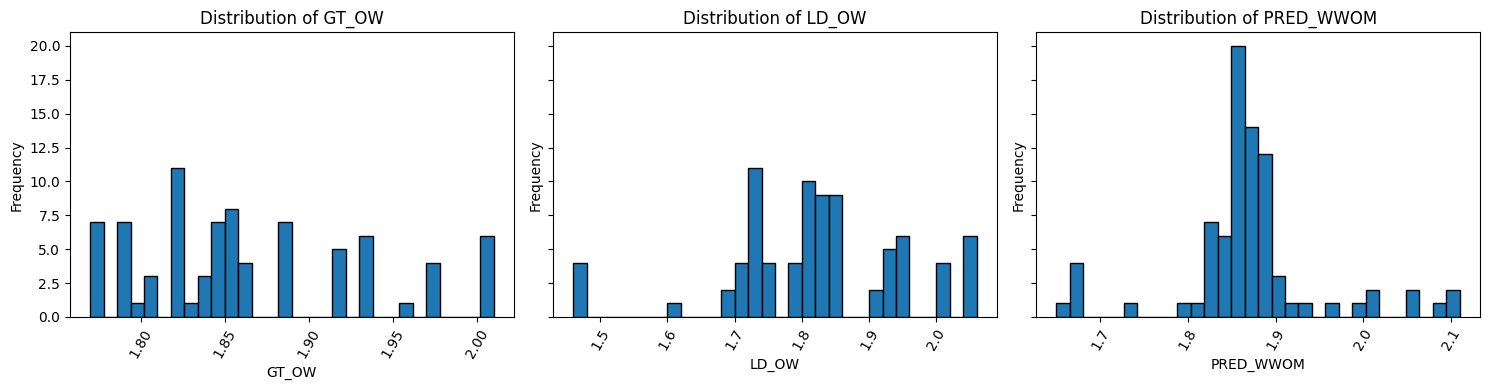

In [62]:
import matplotlib.pyplot as plt

target_df = df1
target_df = target_df.apply(get_gt_dims, axis = 1)
target_df = target_df.dropna()
target_df = target_df.apply(get_types, axis = 1)

target_df[f'PRED_{width_used}'] = pd.to_numeric(target_df[f'PRED_{width_used}'], errors="coerce")
target_df["GT_OW"] = pd.to_numeric(target_df["GT_OW"], errors="coerce")
target_df["LD_OW"] = pd.to_numeric(target_df["LD_OW"], errors="coerce")
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)  # 1 row, 3 columns

for ax, col in zip(axes, ["GT_OW",  "LD_OW", f'PRED_{width_used}']):
    ax.hist(target_df[col], bins=30, edgecolor='black')
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=60)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

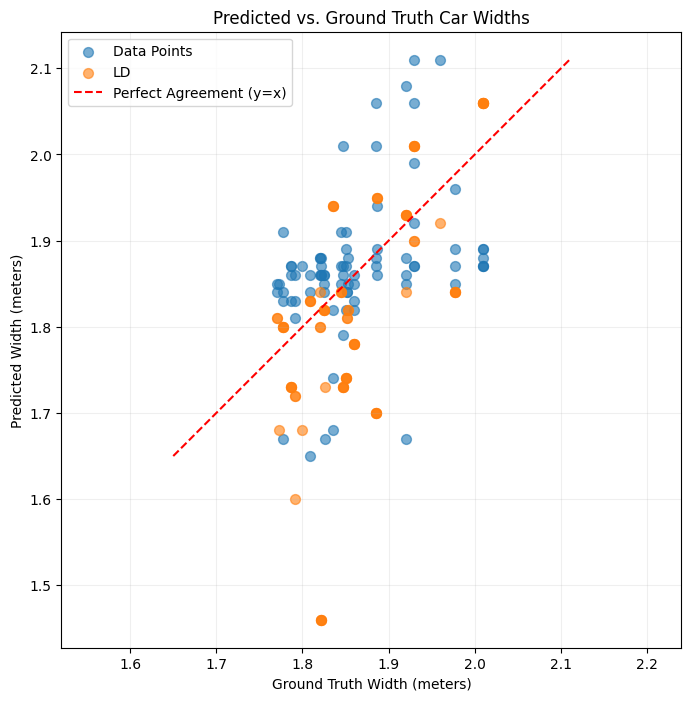

In [46]:
import matplotlib.pyplot as plt

target_df[f'PRED_{width_used}'] = pd.to_numeric(target_df[f'PRED_{width_used}'], errors="coerce")
target_df["GT_OW"] = pd.to_numeric(target_df["GT_OW"], errors="coerce")
target_df["LD_OW"] = pd.to_numeric(target_df["LD_OW"], errors="coerce")

plt.figure(figsize=(8, 8))
plt.scatter(target_df['GT_OW'], target_df[f'PRED_{width_used}'], alpha=0.6, s=50, label='Data Points')
plt.scatter(target_df['GT_OW'], target_df['LD_OW'], alpha=0.6, s=50, label='LD')

# Add reference line (y=x)
min_val = min(target_df['GT_OW'].min(), target_df[f'PRED_{width_used}'].min())
max_val = max(target_df['GT_OW'].max(), target_df[f'PRED_{width_used}'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Agreement (y=x)')

# Customize plot
plt.title('Predicted vs. Ground Truth Car Widths')
plt.xlabel('Ground Truth Width (meters)')
plt.ylabel('Predicted Width (meters)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.axis('equal')  # Equal scaling for x and y axes
plt.show()

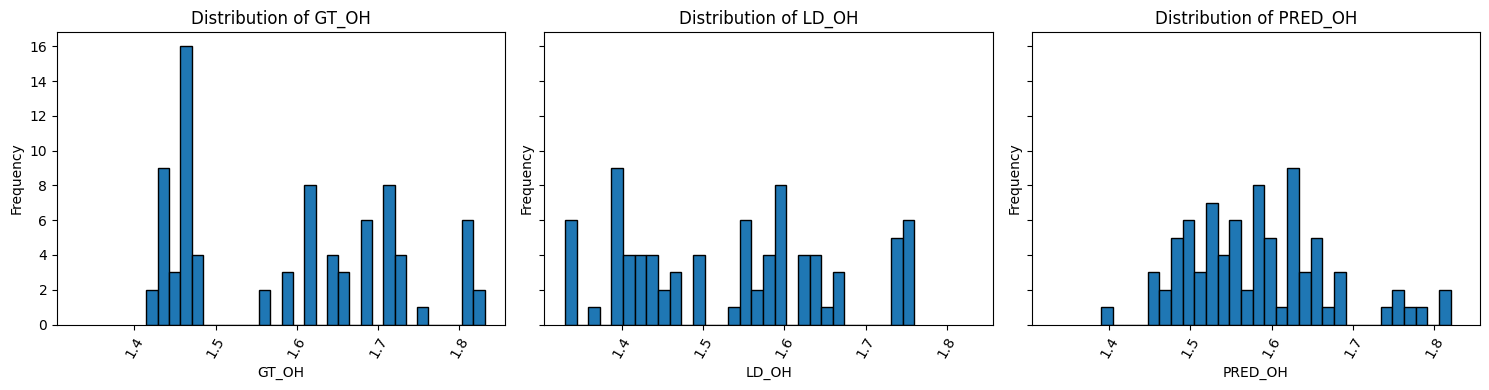

In [60]:
import matplotlib.pyplot as plt

target_df = df1
target_df = target_df.apply(get_gt_dims, axis = 1)
target_df = target_df.dropna()
target_df = target_df.apply(get_types, axis = 1)
metric = 'OH'

target_df[f'PRED_{metric}'] = pd.to_numeric(target_df[f'PRED_{metric}'], errors="coerce")
target_df[f"GT_{metric}"] = pd.to_numeric(target_df[f"GT_{metric}"], errors="coerce")
target_df[f"LD_{metric}"] = pd.to_numeric(target_df[f"LD_{metric}"], errors="coerce")
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, sharex=True)  # 1 row, 3 columns

for ax, col in zip(axes, [f"GT_{metric}", f"LD_{metric}", f'PRED_{metric}']):
    ax.hist(target_df[col], bins=30, edgecolor='black')
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=60)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

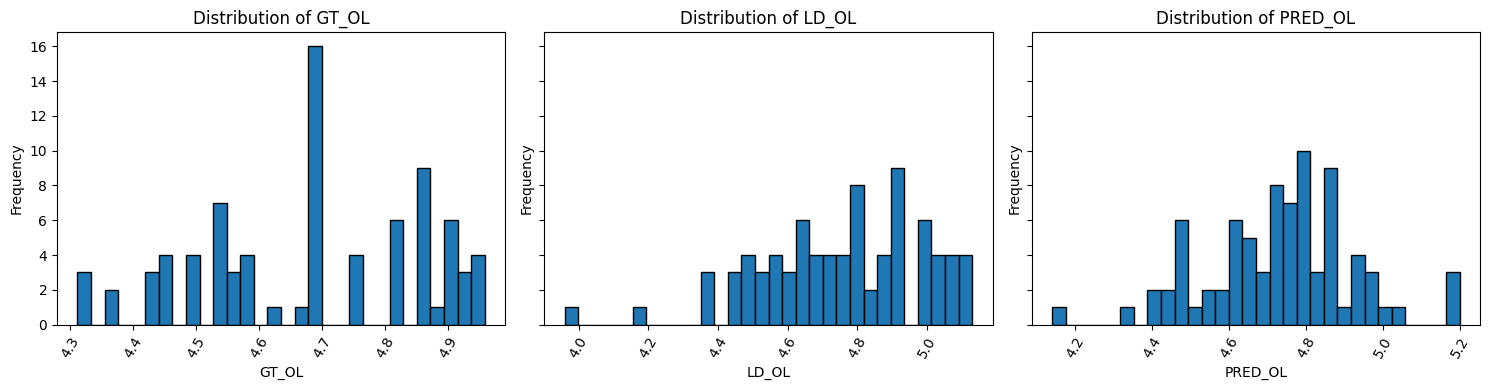

In [57]:
import matplotlib.pyplot as plt

target_df = df1
target_df = target_df.apply(get_gt_dims, axis = 1)
target_df = target_df.dropna()
target_df = target_df.apply(get_types, axis = 1)
metric = 'OL'

target_df[f'PRED_{metric}'] = pd.to_numeric(target_df[f'PRED_{metric}'], errors="coerce")
target_df[f"GT_{metric}"] = pd.to_numeric(target_df[f"GT_{metric}"], errors="coerce")
target_df[f"LD_{metric}"] = pd.to_numeric(target_df[f"LD_{metric}"], errors="coerce")
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)  # 1 row, 3 columns

for ax, col in zip(axes, [f"GT_{metric}", f"LD_{metric}", f'PRED_{metric}']):
    ax.hist(target_df[col], bins=30, edgecolor='black')
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=60)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
lidar= True
# target_df = df1[df1.tire_both_sides.astype(bool)]
target_df = df1
target_df = target_df.apply(get_gt_dims, axis = 1)
target_df = target_df.dropna()
print(len(target_df))
target_df = target_df.apply(get_types, axis = 1)

target_df = target_df.apply(lambda row: compare_dims(row, lidar=lidar), axis = 1)
critical_dims =  ["OH","OL",width_used]
for c in critical_dims:
    target_df[f"ABS_DIFF_{c}"] = target_df[f"DIFF_{c}"].apply(abs)
target_df = target_df.apply(lambda row: eval_diff_percent(row, lidar=lidar), axis = 1)
metrics =[f"DIFF_{c}" for c in critical_dims] + [f"ABS_DIFF_{c}" for c in critical_dims] + [f"ABS_DIFF_PERCENT_{c}" for c in critical_dims]
out_df1 = target_df[metrics]
# out_df1 = out_df1[out_df1[f'ABS_DIFF_{width_used}'] <=1]
print(f'LIDAR = {lidar} method\n', generate_out_df(out_df1))  
# out_df1[metrics_length].describe().round(2)[:2]

81
LIDAR method
 \begin{table}[h]
\begin{tabular}{lr}
\toprule
 & 0 \\
\midrule
\textbf{DIFF Height (m)} & -0.05583 \\
\textbf{DIFF Length (m)} & 0.07558 \\
\textbf{DIFF Width (m)} & -0.04713 \\
\textbf{MAE Height (m)} & 0.07178 \\
\textbf{MAE Length (m)} & 0.11931 \\
\textbf{MAE Width (m)} & 0.08220 \\
\textbf{Mean percentage of Absolute Error over groundtruth vehicle’s Height} & 4.47986 \\
\textbf{Mean percentage of Absolute Error over groundtruth vehicle’s Length} & 2.55179 \\
\textbf{Mean percentage of Absolute Error over groundtruth vehicle’s Width} & 4.41837 \\
\textbf{Number of vehicles} & 81.00000 \\
\bottomrule
\end{tabular}
\end{table}



In [25]:
lidar= False
# target_df = df1[df1.tire_both_sides.astype(bool)]
target_df = df1
target_df = target_df.apply(get_gt_dims, axis = 1)
target_df = target_df.dropna()
target_df = target_df.apply(get_types, axis = 1)

type_selected = 3
target_df = target_df[target_df['type'] == type_selected]
print('Category:', type_selected)

#Some Filtering
# target_df = target_df[target_df.PRED_WB != -1] 
# target_df = target_df[target_df.tire_both_sides == 1] 

target_df = target_df.apply(lambda row: compare_dims(row, lidar=lidar), axis = 1)
# critical_dims = ["OH","OL",width_used]
# critical_dims = ["WB"]
for c in critical_dims:
    # print(c)
    target_df[f"ABS_DIFF_{c}"] = target_df[f"DIFF_{c}"].apply(abs)
    # print(target_df[['target','annotated_car_id',f"DIFF_{c}","dist_base_gt_bbox","iou_bev"]])

target_df = target_df.apply(lambda row: eval_diff_percent(row, lidar=lidar), axis = 1)
metrics =[f"DIFF_{c}" for c in critical_dims] + [f"ABS_DIFF_{c}" for c in critical_dims] + [f"ABS_DIFF_PERCENT_{c}" for c in critical_dims]


# metrics = ['iou', 
#     'dist_base_bbox_diff_abs', 
#     'angle_difference',f'ABS_DIFF_{width_used}']

# print(metrics)
out_df2 = target_df[metrics]

# out_df2 = out_df2[out_df2[f'ABS_DIFF_{width_used}'] <=1]
# print('OUR\n', generate_out_df(out_df2))


out_df2[metrics_width].describe().round(2)[:2]
print(f'N={len(out_df2)}')
print(out_df2[metrics_width].mean().to_latex(index=True,
                      formatters={"name": str.upper},
                      float_format="{:.2f}".format,
                      multirow=True,
                      multicolumn=True,
                      multicolumn_format='c',
                      position='h',
                     bold_rows=True))

# ### Correlation metrics
# # Calculate the Pearson correlation coefficient
# correlation_matrix = target_df[metrics + ['num_sym_pairs']].corr()

# # Extracting the correlations of 'num_sym_pairs' with other metrics
# correlation_with_num_sym_pairs = correlation_matrix['num_sym_pairs'].drop('num_sym_pairs')
# print(correlation_with_num_sym_pairs.to_latex(index=True,
#                       formatters={"name": str.upper},
#                       float_format="{:.2f}".format,
#                       multirow=True,
#                       multicolumn=True,
#                       multicolumn_format='c',
#                       position='h',
#                      bold_rows=True))

Category: 3
N=41
\begin{table}[h]
\begin{tabular}{lr}
\toprule
 & 0 \\
\midrule
\textbf{DIFF_WWOM} & -0.00 \\
\textbf{ABS_DIFF_WWOM} & 0.05 \\
\textbf{ABS_DIFF_PERCENT_WWOM} & 2.57 \\
\bottomrule
\end{tabular}
\end{table}



SyntaxError: unexpected character after line continuation character (1603576566.py, line 3)

In [31]:
#Find the average distance to move for category 4 - bias estimated
type_excluded = 4
target_df = target_df[target_df['type'] != type_excluded]
target_df = target_df[(target_df.dist_to_move > 0)]
print('Category excluded:', type_excluded)
print('sum',target_df[(target_df.dist_to_move > 0)]['dist_to_move'].sum())
print('count',target_df[(target_df.dist_to_move > 0)]['dist_to_move'].count())
print('mean',target_df[(target_df.dist_to_move > 0)]['dist_to_move'].mean())

Category excluded: 4
sum 14.99
count 118
mean 0.12703389830508474


In [32]:
target_df.loc[:, 'ORIG_PRED_WWOM'] = target_df['PRED_WWOM'] - target_df['dist_to_move']
target_df.loc[:,'DIFF_WWOM_ORIG_PRED_WWOM'] = target_df['ORIG_PRED_WWOM'] - target_df['GT_OW']
#Find the average distance to move for category 4 - bias against GT - only cat 1,2,3 valid
print("Compare original pred WWOM to GT")
print('Category excluded:', type_excluded)
print('Sum',target_df.DIFF_WWOM_ORIG_PRED_WWOM.sum())
print('count',target_df.DIFF_WWOM_ORIG_PRED_WWOM.count())
print(target_df.DIFF_WWOM_ORIG_PRED_WWOM.mean())

Compare original pred WWOM to GT
Category excluded: 4
Sum -15.512949999999996
count 118
-0.13146567796610167


In [31]:
(547+462)

1009

In [30]:
(-58.142-65.051)/(547+462)

-0.12209415262636275

In [32]:
(75.45+54.33)/(547+462)

0.12862239841427156

In [ ]:
# target_df[target_df.model == 'Porsche Macan']['LD_OW'].unique()

In [ ]:
# for i in target_df['model'].value_counts().index.to_list():
#     print(i)
#     # print(np.round(target_df[target_df.model == i]['GT_OW'].unique()[0],2))

In [ ]:
# out_df2[metrics_wb].describe()

In [ ]:
# out_df2[metrics_length].describe()

In [ ]:
target_df['type'].value_counts()

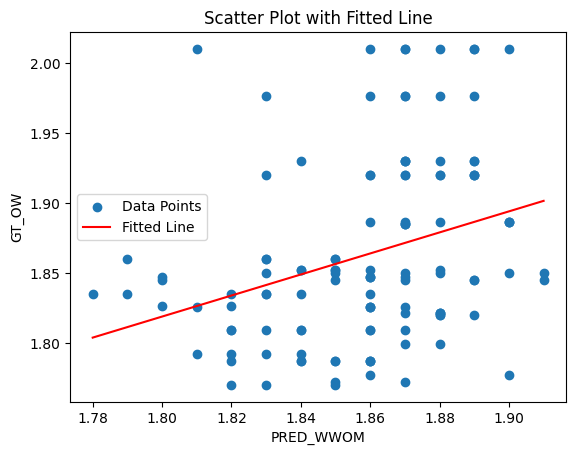

In [33]:
# Extracting the columns to plot
x = target_df['PRED_WWOM']
y = target_df['GT_OW']

# Creating the scatter plot
plt.scatter(x, y, label='Data Points')

# Fitting a straight line
coefficients = np.polyfit(x, y, 1)
line_function = np.poly1d(coefficients)

# Generate x values for the fitted line: from min(x) to max(x)
x_line = np.linspace(min(x), max(x), 100)

# Compute the corresponding y values for the fitted line
y_line = line_function(x_line)

# Adding the fitted line to the scatter plot
plt.plot(x_line, y_line, color='red', label='Fitted Line')

# Adding labels and legend
plt.xlabel('PRED_WWOM')
plt.ylabel('GT_OW')
plt.title('Scatter Plot with Fitted Line')
plt.legend()

# Display the plot
plt.show()

In [34]:
all_dist = []
all_angles = []

for track in target_df.track_name.unique():
    for camera in target_df.camera.unique():
        tdf = target_df[(target_df.track_name == track) & (target_df.camera == camera)]
        if len(tdf) >= 4:
            print(track, len(tdf),'vehicles within track')
            # Calculate the correlation between 'dist_base_gt_bbox' and 'DIFF_WWOM'
            correlation_dist_base_diff = tdf['dist_base_gt_bbox'].corr(tdf[f'ABS_DIFF_{width_used}'])
            # Calculate the correlation between 'gt_heading_angle' and 'DIFF_WWOM'
            correlation_gt_heading_diff = tdf['gt_heading_angle'].corr(tdf[f'ABS_DIFF_{width_used}'])
            print(f"Correlation between 'dist_base_gt_bbox' and 'ABS_DIFF_{width_used}:", correlation_dist_base_diff)
            print(f"Correlation between 'gt_heading_angle' and 'ABS_DIFF_{width_used}:", correlation_gt_heading_diff)
            all_dist.append(correlation_dist_base_diff)
            all_angles.append(correlation_gt_heading_diff)
            print("=====")
print(np.nanmean(all_dist),f'distance factor ABS_DIFF_{width_used}')
print(np.nanmean(all_angles),f'angle factor ABS_DIFF_{width_used}')
print(len(all_dist),'num tracks evals')

204817D2-7AB4-4645-BE94-FBF65279C4D5 4 vehicles within track
Correlation between 'dist_base_gt_bbox' and 'ABS_DIFF_WWOM: -0.7481286925820464
Correlation between 'gt_heading_angle' and 'ABS_DIFF_WWOM: -0.5080868905376984
=====
-0.7481286925820464 distance factor ABS_DIFF_WWOM
-0.5080868905376984 angle factor ABS_DIFF_WWOM
1 num tracks evals


In [ ]:
all_dist = []
all_angles = []

for track in target_df.track_name.unique():
    for camera in target_df.camera.unique():
        tdf = target_df[(target_df.track_name == track) & (target_df.camera == camera)]
        if len(tdf) >= 4:
            # print(track, len(tdf),'vehicles within track')
            # Calculate the correlation between 'dist_base_gt_bbox' and 'DIFF_WWOM'
            correlation_dist_base_diff = tdf['dist_base_gt_bbox'].corr(tdf['ABS_DIFF_OL'])
            # Calculate the correlation between 'gt_heading_angle' and 'DIFF_WWOM'
            correlation_gt_heading_diff = tdf['gt_heading_angle'].corr(tdf['ABS_DIFF_OL'])
            # print("Correlation between 'dist_base_gt_bbox' and 'ABS_DIFF_OL':", correlation_dist_base_diff)
            # print("Correlation between 'gt_heading_angle' and 'ABS_DIFF_OL':", correlation_gt_heading_diff)
            all_dist.append(correlation_dist_base_diff)
            all_angles.append(correlation_gt_heading_diff)
            # print("=====")
print(np.nanmean(all_dist),'distance factor ABS_DIFF_OL')
print(np.nanmean(all_angles),'angle factor ABS_DIFF_OL')
print(len(all_dist),'num tracks evals')

In [ ]:
# out_df2[metrics_length].describe()

In [ ]:
# # Adjusting display options to show the full DataFrame content in Jupyter Notebook
# pd.set_option('display.max_colwidth', None)  # Ensure full display of Metric column

# # Define the extended data for the DataFrame
# extended_data = {
#     'Metric': ['Distance ABS_DIFF_WWOM Mean Absolute Pearson-Corr', 'Heading Angle ABS_DIFF_WWOM Mean Absolute Pearson-Corr',
#                'Distance ABS_DIFF_OL Mean Absolute Pearson-Corr', 'Heading Angle ABS_DIFF_OL Mean Absolute Pearson-Corr', 'Num Tracks Evals'],
#     'COOP': [0.5221708545579201, 0.5051796210939099, 0.5232460648001386, 0.4923575684685045, 102],
#     'HW7': [0.4321459500852805, 0.4760806293985892, 0.5808527224078526, 0.5299566640614521, 58]
# }

# # Create the extended DataFrame
# extended_df = pd.DataFrame(extended_data)
# extended_df

#### OLD

In [ ]:
track_path = Path(f'/mnt/c/Projects_raw_data/HW7/saved_tracks')

In [ ]:
#Load the results in here as a dataframe 
result_path = Path('compare_data')

In [ ]:
#Name the columns
col_names = ["target", "annotated_car_id",
       "num_sym_pairs","bbox_2D_height",
             "reproj_error","gt_heading_angle",
             "pred_heading_angle","angle_difference",
             "dist_base_gt_bbox","dist_base_pred_bbox",
             "dist_base_bbox_diff","dist_nearest_corner_gt_bbox",
             "dist_nearest_corner_pred_bbox","dist_nearest_corner_diff",
             "iou","iou_bev","mounting_height","ds",
            "PRED_OL","PRED_OW","PRED_OH","PRED_WB","LD_OL","LD_OW","LD_OH"]

In [ ]:
def get_gt_dims(row):
    lookup_str = f"{str(int(row.target)).zfill(4)}_{int(row.annotated_car_id-1)}" #Difference between python index 0 and matlab index 1    
    if lookup_str in car_to_track: #Gotta have results from the pipeline
        track_name = car_to_track[lookup_str]
        if track_name in all_seqs_make_model[str(intersection_begin)]: #Gotta have gt dimension
            model_detect = all_seqs_make_model[str(intersection_begin)][track_name]
            row["model"] = list(model_detect.keys())[0]
            for k,v in model_detect[row.model].items():
                row[f"GT_{k}"] = v/100 #Convert to meter
    return row

In [ ]:
def compare_dims(row, lidar=False):
    if lidar:
        critical_dims = ["OH","OL","OW"]
    else:
        critical_dims = ["OH","OL","OW","WB"]
    for c in critical_dims:
        if lidar:
            row[f"DIFF_{c}"] = row[f"LD_{c}"]-row[f"GT_{c}"]
        else:
            row[f"DIFF_{c}"] = row[f"PRED_{c}"]-row[f"GT_{c}"]
    return row

In [ ]:
def eval_diff_percent(row,lidar):
    if lidar:
        critical_dims = ["OH","OL","OW"]
    else:
        critical_dims = ["OH","OL","OW","WB"]
    for c in critical_dims:
        row[f"ABS_DIFF_PERCENT_{c}"] = round(row[f"ABS_DIFF_{c}"]/row[f"GT_{c}"]*100,3)
    return row

In [ ]:
def display_results(annotator,lidar,merged_df):
    fname = f'{intersection_begin}_{annotator}_{suffix}.txt'
    df = pd.read_csv(result_path/fname, delim_whitespace=True, header=None)
    assert len(col_names) == df.shape[-1]
    df.columns = col_names
    df = df.apply(get_gt_dims, axis = 1)
    gdf = df.dropna()
    gdf = gdf[gdf.PRED_WB != -1]
    gdf = gdf.apply(lambda row: compare_dims(row, lidar=lidar), axis = 1)
    
    # align indices
    gdf = gdf.set_index(['target', 'annotated_car_id'])
    merged_df = merged_df.set_index(['target', 'annotated_car_id'])
    gdf = gdf[gdf.index.isin(merged_df.index)].reset_index()   
    print('Num records',len(gdf))
    if lidar:
        critical_dims = ["OH","OL","OW"]
    else:
        critical_dims = ["OH","OL","OW","WB"]
    for c in critical_dims:
        gdf[f"ABS_DIFF_{c}"] = gdf[f"DIFF_{c}"].apply(abs)
    #Print out results
    print(intersection_begin, i,f"Lidar-derived:{lidar}", suffix)
    gdf = gdf.apply(lambda row: eval_diff_percent (row,lidar=lidar), axis = 1)
    if lidar:
        for c in critical_dims:
            print(f"ABS_DIFF_{c}",round(gdf[f"ABS_DIFF_{c}"].mean(),2))
        for c in critical_dims:
            print(f"ABS_DIFF_PERCENT_{c}",round(gdf[f"ABS_DIFF_PERCENT_{c}"].mean(),2))
    else:
        diff = []
        diff_percent = []
        for c in critical_dims:
            diff.append(gdf[f"ABS_DIFF_{c}"].mean())
        for c in critical_dims:
            diff_percent.append(gdf[f"ABS_DIFF_PERCENT_{c}"].mean())
        return diff, diff_percent

In [ ]:
def get_exist_in_both(intersection_begin,annotator,suffix):
    fname = f'{intersection_begin}_{annotator}_{suffix}.txt'
    df = pd.read_csv(result_path/fname, delim_whitespace=True, header=None)
    assert len(col_names) == df.shape[-1]
    df.columns = col_names
    df = df.apply(get_gt_dims, axis = 1)
    gdf = df.dropna()
    gdf = gdf[gdf.PRED_WB != -1]
    return gdf[['target', 'annotated_car_id']]

In [ ]:
track_path.resolve()

In [ ]:
annotators = ['thao','thao']
suffix = '20231013'
track_suffix = '20231011'
lidars = [True, False]
segment = "Seg23"
intersections = ["seg23_sc2"]
camera = "sc2"
for intersection_begin in intersections:
    #Processing track
    with open(f"{str(track_path)}/{segment}/{camera}/{segment}_{camera}_{track_suffix}.json","r") as f:
        tracks = json.load(f)
    car_to_track = dict()
    for k,v in tracks.items():
        for i in v:
            car_to_track[i] = k
            
    #Combined common results only for better results
    all_dfs = []    
    for i in annotators:
        one_df = get_exist_in_both(intersection_begin,i,suffix)
        all_dfs.append(one_df)
    merged_df = all_dfs[0].merge(all_dfs[1], on=['target', 'annotated_car_id'], how='inner')
    two_annos_diff = []
    two_annos_diff_percent = []
    for i in annotators:
        diff, diff_percent = display_results(annotator=i,lidar=False,merged_df=merged_df)
        two_annos_diff.append(diff)
        two_annos_diff_percent.append(diff_percent)
    two_annos_diff = np.array(two_annos_diff)
    two_annos_diff_percent = np.array(two_annos_diff_percent)
    print(np.round(np.mean(two_annos_diff,0),2))
    print(np.around(np.mean(two_annos_diff_percent,0),2))
    display_results(annotator='thao',lidar=True,merged_df=merged_df)
    print("=================")
#     break

In [ ]:
fname = f'{intersection_begin}_{annotator}_{suffix}.txt'
print(fname)

In [ ]:
df = pd.read_csv(result_path/fname, delim_whitespace=True, header=None)

In [ ]:
#Name the columns
col_names = ["target", "annotated_car_id",
       "num_sym_pairs","bbox_2D_height",
             "reproj_error","gt_heading_angle",
             "pred_heading_angle","angle_difference",
             "dist_base_gt_bbox","dist_base_pred_bbox",
             "dist_base_bbox_diff","dist_nearest_corner_gt_bbox",
             "dist_nearest_corner_pred_bbox","dist_nearest_corner_diff",
             "iou","iou_bev","mounting_height","ds","time_diff",
            "PRED_OL","PRED_OW","PRED_OH","PRED_WB","LD_OL","LD_OW","LD_OH"]
assert len(col_names) == df.shape[-1]

In [ ]:
df.columns = col_names

In [ ]:
df

In [ ]:
# all_seqs_make_model

In [ ]:
#Look up the groundtruth dimensions and put into the dataframe along with the make and model

In [ ]:
df = df.apply(get_gt_dims, axis = 1)

In [ ]:
#Compare the difference

In [ ]:
gdf = df.dropna()
gdf = gdf[gdf.PRED_WB != -1]

In [ ]:
# def compare_dims(row):
#     for c in critical_dims:
#         row[f"DIFF_{c}"] = row[f"PRED_{c}"]-row[f"GT_{c}"]
#     return row

In [ ]:
lidar=False

In [ ]:
gdf = gdf.apply(lambda row: compare_dims(row, lidar=lidar), axis = 1)

In [ ]:
for c in critical_dims:
    gdf[f"ABS_DIFF_{c}"] = gdf[f"DIFF_{c}"].apply(abs)

In [ ]:
if lidar:
    critical_dims = ["OH","OL","OW"]
else:
    critical_dims = ["OH","OL","OW","WB"]

In [ ]:
for c in critical_dims:
    print(f"ABS_DIFF_{c}")
    print(round(gdf[f"ABS_DIFF_{c}"].mean(),2))
    print("===")
print(len(gdf))

In [ ]:
gdf = gdf.apply(eval_diff_percent, axis = 1)

In [ ]:
for c in critical_dims:
    print(f"ABS_DIFF_PERCENT_{c}")
    print(round(gdf[f"ABS_DIFF_PERCENT_{c}"].mean(),2))
    print("===")

### efor

### Car models

In [ ]:
gdf[["target", "annotated_car_id", "model"]]

In [ ]:
gdf.model.value_counts()